In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import seaborn as sns

data=pd.read_csv('./Cardiovascular_Disease_Dataset.csv')
data.isnull().sum()
data.head()

data['age']=(data['age']/365).astype('int')
#sns.heatmap(data.corr(), annot=True, cmap='Blues')



In [10]:
X=data.drop(['target'],axis=1)

y=data['target']
X_scaled=StandardScaler().fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=42)
X

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels
0,103368,0,1,2,171,0,0,1,147,0,5.3,3,3
1,119250,0,1,0,94,229,0,1,115,0,3.7,1,1
2,119372,0,1,2,133,142,0,0,202,1,5.0,1,0
3,132514,0,1,0,138,295,1,1,153,0,3.2,2,2
4,146211,0,1,1,199,0,0,2,136,0,5.3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,9949544,0,1,2,139,349,0,2,183,1,5.6,2,2
996,9953423,0,1,3,143,258,1,1,98,1,5.7,1,0
997,9965859,0,1,0,156,434,1,0,196,0,1.4,3,1
998,9988507,0,1,1,186,417,0,1,117,1,5.9,3,2


In [11]:
from tensorflow.keras import models
from tensorflow.keras.layers import Dense,Dropout


model=models.Sequential([
    Dense(128,activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.4),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history=model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.2)
model.summary

/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5917 - loss: 0.6548 - val_accuracy: 0.7143 - val_loss: 0.5476
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7679 - loss: 0.4820 - val_accuracy: 0.8857 - val_loss: 0.3784
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8873 - loss: 0.3534 - val_accuracy: 0.9071 - val_loss: 0.2579
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9213 - loss: 0.2240 - val_accuracy: 0.9143 - val_loss: 0.2283
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9369 - loss: 0.2013 - val_accuracy: 0.9286 - val_loss: 0.2002
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9348 - loss: 0.1634 - val_accuracy: 0.9286 - val_loss: 0.1876
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9489 - loss: 0.1314 - val_accuracy: 0.9286 - val_loss: 0.1743
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9523 - loss: 0.1438 - val_accuracy: 0.9429 - va

<bound method Model.summary of <Sequential name=sequential_2, built=True>>

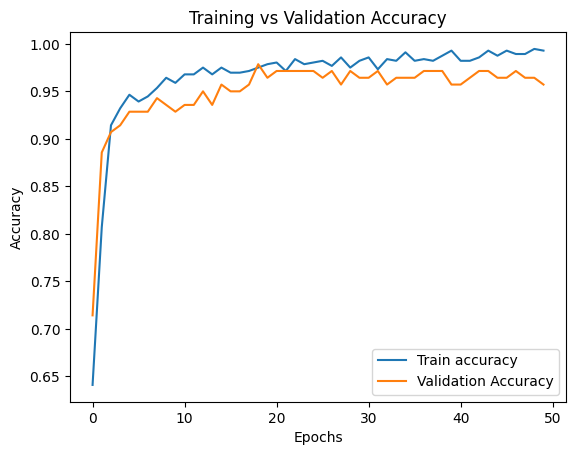

In [12]:
plt.plot(history.history["accuracy"],label='Train accuracy')
plt.plot(history.history["val_accuracy"],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9661 - loss: 0.0939 
Test Accuracy: 0.9733
